# Data Preprocessing for Topic Modelling

In [1]:
!pip install pandas nltk wordcloud matplotlib

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [2]:
INPUT_FILE     = "kfc_sentiment_labelled_full.csv"
OUTPUT_FILE    = "kfc_negative_comments.csv"
WORDCLOUD_FILE = "wordcloud_negative_comments.png"

In [4]:
TOPIC_STOPWORDS = set(stopwords.words("english")).union({
    "kfc", "kentucky", "fried", "kfcs","drive", "thru", "fast", "food", "order", "ordered", "restaurant",
    "meal", "staff", "location", "customer", "service", "place", "menu",
    "eat", "eating", "ate", "review", "experience", "visit", "visited",
    "store", "branch", "delivery", "deliveroo", "uber","got", "get", "could", "also", "like", "do", "does", "did",
    "have", "has", "having", "be", "was", "been", "had", "make",
    "go", "going", "went", "come", "came", "look", "take", "keep",
    "try", "trying", "buy", "pay", "give", "let", "put", "call",
    "tell", "ask", "find", "leave", "making", "working", "getting",
    "say", "said", "think", "see", "need", "want", "used", "use",
    "work", "know", "good", "better", "right", "sure", "pretty", "different", "big",
    "small", "whole", "single", "normal", "hard", "real", "full",
    "likely", "able", "enough", "great", "nice", "best", "new", "well", "definitely", "literally", "probably", "maybe", "might",
    "exactly", "already", "anymore", "instead", "unless", "either",
    "around", "away", "another", "first", "half", "actually", "really", "much", "even", "still", "just",
    "time", "now", "then", "there", "when", "day", "year", "today",
    "always", "ago", "last", "week", "hour", "long", "done", "they", "them", "you", "me", "my", "he", "she", "we", "him",
    "her", "our", "ours", "yours", "theirs", "their", "i", "the", "a", "an", "this", "that", "these", "those", "its", "to", "of", "in", "on", "at", "from", "with", "about", "for",
    "and", "but", "or", "if", "as", "so", "because", "though","what", "which", "who", "whom", "whose", "how", "where", "why", "is", "are", "am", "was", "were", "will", "would", "can",
    "could", "should", "shall", "im", "dont", "didnt", "theyll", "youre", "ive", "theyre",
    "thats", "yeah", "lol", "lmao", "cant", "wont", "isnt",
    "wasnt", "arent", "wouldnt", "id", "yes", "etc", "msg", "bit", "old", "not", "thing", "lot", "part", "point", "reason", "case", "fact",
    "hand", "end", "life", "world", "stuff", "amount", "guy",
    "person", "everyone", "someone", "people", "something", "back",
    "one", "two", "way", "fuck", "shit", "fucking", "damn", "stupid", "crazy",
    "suck", "ass", "crap", "crappy", "shitty",
})

In [8]:
#negative filter
df = pd.read_csv(INPUT_FILE)
print(f"Full dataset: {len(df)}")
print(df["Sentiment"].value_counts())

df_neg = df[df["Sentiment"] == "Negative"].copy()
print(f"\nNegative comments: {len(df_neg)}")

Full dataset: 18920
Sentiment
Neutral     12236
Negative     4113
Positive     2571
Name: count, dtype: int64

Negative comments: 4113


In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"/[ur]/\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_for_topics(text):
    lemmatizer = WordNetLemmatizer()
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = [t for t in tokens if t not in TOPIC_STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df_neg["Tokenised_Comment"] = df_neg["Comment"].apply(preprocess_for_topics)

before = len(df_neg)
df_neg = df_neg[df_neg["Tokenised_Comment"].str.strip().astype(bool)]
print(f"Removed {before - len(df_neg)} empty rows")
print(f"Final: {len(df_neg)} negative comments")

Removed 78 empty rows
Final: 4035 negative comments


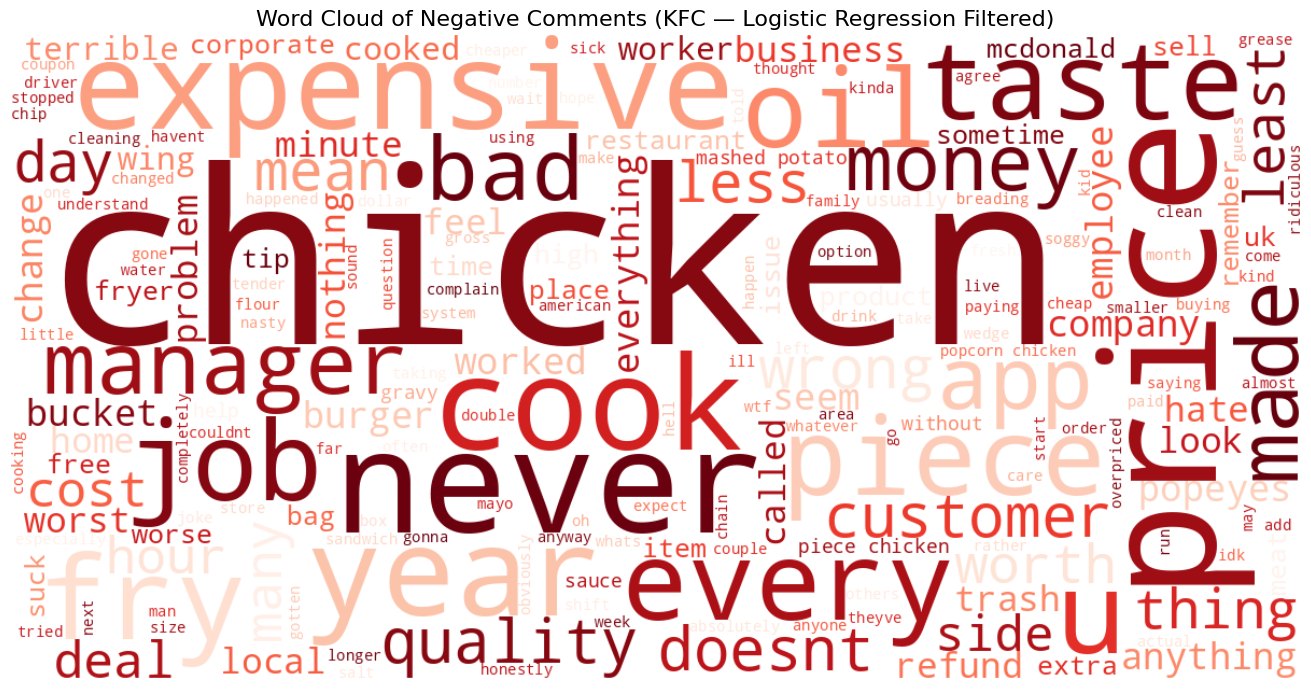

In [11]:
wordcloud = WordCloud(
    width=1200, height=600, background_color="white",
    max_words=200, colormap="Reds",
).generate(" ".join(df_neg["Tokenised_Comment"]))

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Word Cloud of Negative Comments (KFC — Logistic Regression Filtered)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig(WORDCLOUD_FILE, dpi=150)
plt.show()

In [12]:
df_neg.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_FILE}")
print(f"Negative comments: {len(df_neg)}")

Saved: kfc_negative_comments.csv
Negative comments: 4035
